In [1]:
!pip install nibabel
!pip install pydicom

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.4/2.4 MB 97.1 MB/s eta 0:00:00


In [3]:
import os
import numpy as np
import pydicom
import matplotlib.pyplot as plt

## load the dataset

In [28]:
from google.colab import drive
drive.mount('/content/drive')
slices=[]
# Load single DICOM file
dicom_file = "CT000000.dcm"
ds = pydicom.dcmread(dicom_file)
slices.append(ds)

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [29]:
slices.sort(key=lambda x: float(x.ImagePositionPatient[2]))
# Stack into volume
ct_volume = np.stack([s.pixel_array for s in slices], axis=0)
print("CT Volume Shape (Z, Y, X):", ct_volume.shape)
# convert raw CT pixel data to Hounsfield Units (HU)
def to_hu(slices, volume):
  hu = volume.astype(np.int16)
  for i, s in enumerate(slices):
    intercept = s.RescaleIntercept
    slope = s.RescaleSlope
    hu[i] = hu[i] * slope + intercept
  return hu
ct_hu = to_hu(slices, ct_volume)

CT Volume Shape (Z, Y, X): (1, 512, 512)


In [31]:
print(slices[0])

Dataset.file_meta -------------------------------
(0002,0000) File Meta Information Group Length  UL: 196
(0002,0001) File Meta Information Version       OB: b'\x00\x01'
(0002,0002) Media Storage SOP Class UID         UI: CT Image Storage
(0002,0003) Media Storage SOP Instance UID      UI: 1.2.276.0.7230010.3.1.4.296485376.1.1521714859.2131745
(0002,0010) Transfer Syntax UID                 UI: Implicit VR Little Endian
(0002,0012) Implementation Class UID            UI: 1.2.276.0.7230010.3.0.3.6.2
(0002,0013) Implementation Version Name         SH: 'OFFIS_DCMTK_362'
-------------------------------------------------
(0008,0000) Group Length                        UL: 342
(0008,0005) Specific Character Set              CS: 'ISO_IR 100'
(0008,0008) Image Type                          CS: ['ORIGINAL', 'PRIMARY', 'AXIAL']
(0008,0012) Instance Creation Date              DA: ''
(0008,0013) Instance Creation Time              TM: ''
(0008,0016) SOP Class UID                       UI: CT Image

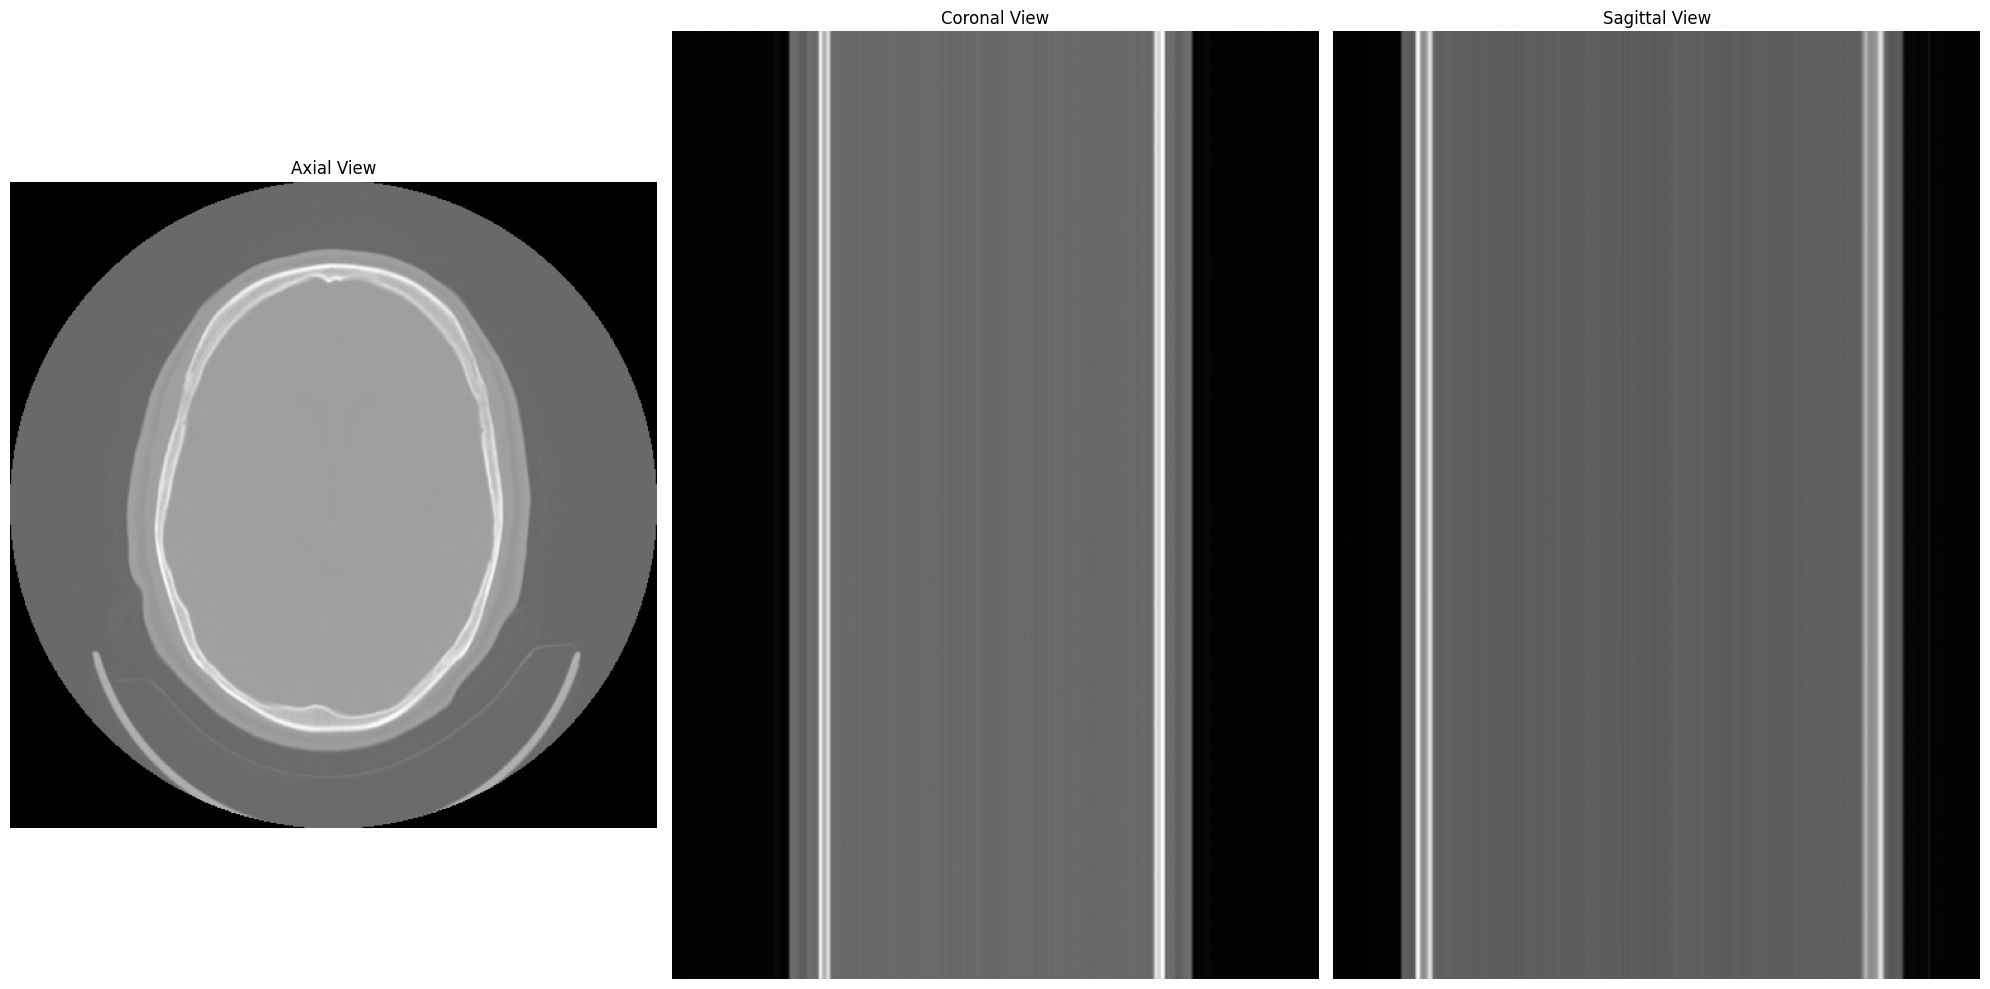

In [32]:
# Middle indices
z_mid = ct_hu.shape[0] // 2
y_mid = ct_hu.shape[1] // 2
x_mid = ct_hu.shape[2] // 2
plt.figure(figsize=(20, 10))
# Axial (Z slice)
plt.subplot(1, 3, 1)
plt.imshow(ct_hu[z_mid, :, :], cmap="gray")
plt.title("Axial View")
plt.axis("off")
# Coronal (Y slice)
plt.subplot(1, 3, 2)
plt.imshow(ct_hu[:, y_mid, :], cmap="gray", aspect='auto')
plt.title("Coronal View")
plt.axis("off")
# Sagittal (X slice)
plt.subplot(1, 3, 3)
plt.imshow(ct_hu[:, :, x_mid], cmap="gray", aspect='auto')
plt.title("Sagittal View")
plt.axis("off")
plt.tight_layout()
plt.show()